In [1]:
import pandas as pd
import numpy as np

# fullDF = pd.read_csv("integrationpipeline_melanoma_IpiDummy/integrated_data_melanoma.csv", index_col = 0)


with open("unexpressedGenes.txt", 'r', encoding='utf-8') as f:
        # Đọc tất cả các dòng vào một list
        raw_lines = f.readlines()

    # Xử lý list để loại bỏ ký tự xuống dòng cho từng phần tử
dropgenes_list = [line.strip() for line in raw_lines]

fullDF = fullDF.drop(columns = dropgenes_list)

genelist = fullDF.iloc[:,55:].columns.tolist()
# generate response groups

responderCrit = fullDF['BR'].isin(['CR','PR'])
progressorCrit = fullDF['BR'].isin(['PD'])

responders = fullDF[responderCrit].index
progressors = fullDF[progressorCrit].index
nonresponders = fullDF[~responderCrit].index
nonprogressors = fullDF[~progressorCrit].index
print(len(responders),"responders")
print(len(progressors),"progressors")

fullDF.loc[responders,"PD vs Responder"] = 'Responder'
fullDF.loc[progressors,"PD vs Responder"] = 'Progressor'

fullDF.loc[responders,"Responder"] = 1
fullDF.loc[progressors,"Responder"] = 0

fullDF["PD vs nonPD"] = 'nonPD'
fullDF.loc[progressors,"PD vs nonPD"] = 'PD'

comparisonGroups = [
    'PD vs Responder',
    'PD vs nonPD',
]

fullDF['Responder'].value_counts()

47 responders
56 progressors


Responder
0.0    56
1.0    47
Name: count, dtype: int64

In [2]:
import math
# generate additional columns
fullDF['log nonsyn mutload'] = [math.log(x,10) for x in fullDF['nonsyn_muts']]
fullDF['log clonal mutload'] = [math.log(x,10) for x in fullDF['clonal_muts']]
fullDF['log subclonal mutload'] = [math.log(x,10) for x in fullDF['subclonal_muts']]
fullDF['log neoantigens'] = [math.log(x,10) for x in fullDF['total_neoantigens']]

# add additional category
fullDF.loc[fullDF.index, 'Primary_Type_Categ'] = "Skin or Occult"
mucosalCrit = fullDF['Primary_Type'] == "mucosal"
acralCrit = fullDF['Primary_Type'] == "acral"
fullDF.loc[mucosalCrit | acralCrit, 'Primary_Type_Categ'] = "Mucosal or Acral"

# add dominant mutational signature
uvDom = (fullDF['UV'] > fullDF['Alkylating']) & (fullDF['UV'] > fullDF['Cosmic'])
alkDom = (fullDF['Alkylating'] > fullDF['UV']) & (fullDF['Alkylating'] > fullDF['Cosmic'])
otherDom = (fullDF['Cosmic'] > fullDF['Alkylating']) & (fullDF['Cosmic'] > fullDF['UV'])

print(sum(uvDom), "tumors with dominant UV signature")
print(sum(alkDom), "tumors with dominant alkylating signature")
print(sum(otherDom), "tumors with dominant other (aging + others) signature")

# add to tumorDF
fullDF.loc[uvDom,"Dominant MutSig"] = 'UV'
fullDF.loc[alkDom,"Dominant MutSig"] = 'Alkylating'
fullDF.loc[otherDom,'Dominant MutSig'] = 'Other'

85 tumors with dominant UV signature
3 tumors with dominant alkylating signature
33 tumors with dominant other (aging + others) signature


In [4]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
import gseapy as gp

phenotype = "PD vs Responder"
overall_df = fullDF[~fullDF[phenotype].isna()]
responders_df = overall_df[overall_df[phenotype]=="Responder"]
progressor_df = overall_df[overall_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in genelist:
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    # if np.mean(progressors_exp) == 0:
    #     print(gene)
    #     progressors_exp = 10e-9
    #     pass
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":genelist, "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
# results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Pvalue"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

In [7]:
rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
hallmarks_gmt = "OriginalData/h.all.v2025.1.Hs.symbols.gmt"
pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_overall = pre_res.res2d

2025-11-20 17:58:13,745 [WARNING] Duplicated values found in preranked stats: 90.88% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-20 17:58:13,745 [INFO] Parsing data files for GSEA.............................
2025-11-20 17:58:13,871 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-20 17:58:13,877 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-20 17:58:13,878 [INFO] Start to run GSEA...Might take a while..................
2025-11-20 17:58:31,563 [INFO] Congratulations. GSEApy runs successfully................



In [9]:
print("---Ipi-Experience---")
phenotype = "PD vs Responder"
ipitreated_df = overall_df[overall_df["daysBiopsyAfterIpiStart"]=="postIpi"]
responders_df = ipitreated_df[ipitreated_df[phenotype]=="Responder"]
progressor_df = ipitreated_df[ipitreated_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in genelist:
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":genelist, "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
# results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Pvalue"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
ipitreated_pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_ipitreated = ipitreated_pre_res.res2d
prerank_ipitreated.head()

---Ipi-Experience---


2025-11-20 17:59:10,361 [WARNING] Duplicated values found in preranked stats: 98.76% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-20 17:59:10,377 [INFO] Parsing data files for GSEA.............................
2025-11-20 17:59:10,421 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-20 17:59:10,424 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-20 17:59:10,425 [INFO] Start to run GSEA...Might take a while..................
2025-11-20 17:59:25,170 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_ALLOGRAFT_REJECTION,0.596871,2.449496,0.0,0.0,0.0,85/184,13.97%,PRKCB;CD28;CTSS;CXCR3;HLA-DMA;TAP2;CD3D;ETS1;M...
1,prerank,HALLMARK_INTERFERON_GAMMA_RESPONSE,0.55683,2.299898,0.0,0.0,0.0,94/194,20.53%,HLA-DMA;PFKP;OASL;SECTM1;CMPK2;IL2RB;ITGB7;IL1...
2,prerank,HALLMARK_INTERFERON_ALPHA_RESPONSE,0.573592,2.147022,0.0,0.0,0.0,44/94,20.53%,OASL;CMPK2;TRIM26;CCRL2;CMTR1;RSAD2;IFI30;B2M;...
3,prerank,HALLMARK_INFLAMMATORY_RESPONSE,0.451885,1.860166,0.0,0.000691,0.0026,58/192,15.56%,SLAMF1;P2RX4;MARCO;CYBB;PIK3R5;FZD5;IL2RB;IL10...
4,prerank,HALLMARK_IL2_STAT5_SIGNALING,0.413797,1.709457,0.0,0.004611,0.0216,57/194,15.66%,CCR4;CTLA4;NOP2;PRKCH;P2RX4;ICOS;IL2RB;IL10RA;...


In [10]:
print("---Ipi-Naive---")
phenotype = "PD vs Responder"
ipitreated_df = overall_df[overall_df["daysBiopsyAfterIpiStart"]=="noIpi"]
responders_df = ipitreated_df[ipitreated_df[phenotype]=="Responder"]
progressor_df = ipitreated_df[ipitreated_df[phenotype]=="Progressor"]
pvalues = []
log2FCs = []
rank_scores = []
for gene in genelist:
    responders_exp = responders_df[gene].values.tolist()
    progressors_exp = progressor_df[gene].values.tolist()
    odd_stat, pvalue = ranksums(responders_exp, progressors_exp, alternative='two-sided')
    log2fc = np.log2(np.mean(responders_exp)/np.mean(progressors_exp))
    pvalues.append(pvalue)
    log2FCs.append(log2fc)


reject, qvalues, _, _ = multipletests(
        pvalues, 
        method='fdr_bh'
    )
results_df = pd.DataFrame(
    {"Gene":genelist, "Pvalue": pvalues, "Q-value": qvalues, "Log2FC": log2FCs}
)
results_df["Rank_score"] = np.sign(results_df["Log2FC"])*(-np.log10(results_df["Q-value"]))
ranked_results_df = results_df.sort_values(by="Rank_score", ascending = False)

rnk = ranked_results_df[["Gene","Rank_score"]].set_index("Gene")
ipinaive_pre_res = gp.prerank(rnk=rnk,
                     gene_sets=hallmarks_gmt,
                     threads=32,
                     permutation_num=10000, # reduce number to speed up testing
                     outdir=None, # don't write to disk
                     seed=42,
                     verbose=True)
prerank_ipinaive = ipinaive_pre_res.res2d
prerank_ipinaive.head()

---Ipi-Naive---


2025-11-20 17:59:54,735 [WARNING] Duplicated values found in preranked stats: 99.09% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2025-11-20 17:59:54,749 [INFO] Parsing data files for GSEA.............................
2025-11-20 17:59:54,820 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2025-11-20 17:59:54,821 [INFO] 0050 gene_sets used for further statistical testing.....
2025-11-20 17:59:54,821 [INFO] Start to run GSEA...Might take a while..................
2025-11-20 18:00:09,628 [INFO] Congratulations. GSEApy runs successfully................



,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,HALLMARK_E2F_TARGETS,0.471021,2.647382,0.0,0.0,0.0,86/198,21.10%,EXOSC8;HMMR;CTPS1;NCAPD2;MLH1;MCM2;NOLC1;MXD3;...
1,prerank,HALLMARK_G2M_CHECKPOINT,0.431752,2.397496,0.0,0.0,0.0,82/193,20.41%,CUL4A;HMMR;HNRNPU;NUP50;MCM2;NOLC1;SFPQ;RACGAP...
2,prerank,HALLMARK_MYC_TARGETS_V2,0.461712,2.090568,0.0,0.000989,0.0003,19/57,18.10%,RCL1;NOLC1;NOP2;MPHOSPH10;RRP12;NOP56;HK2;PPAN...
3,prerank,HALLMARK_ALLOGRAFT_REJECTION,0.355168,1.981064,0.0,0.002473,0.001,60/184,17.82%,MMP9;CAPG;FLNA;CFP;IL16;IRF8;CDKN2A;CD3G;CCL22...
4,prerank,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,0.450203,1.956305,0.0,0.002374,0.0012,19/49,17.91%,PFKP;LSP1;FES;STK25;SELENOS;OXSR1;ABCC1;GPX4;N...


In [11]:
pathways = ["HALLMARK_INTERFERON_GAMMA_RESPONSE","HALLMARK_INTERFERON_ALPHA_RESPONSE"]
subgroups = ["Overall","Ipi-Exp","Ipi-Naive"]
graphDFs = []
for pathway in pathways:
    overall_qvalue = prerank_overall[prerank_overall["Term"]==pathway]["FDR q-val"].values
    ipitreated_qvalue = prerank_ipitreated[prerank_ipitreated["Term"]==pathway]["FDR q-val"].values
    ipinaive_qvalue = prerank_ipinaive[prerank_ipinaive["Term"]==pathway]["FDR q-val"].values
    graphDF = pd.DataFrame(
        {"Subgroup": subgroups,
         "FDR q-value": [float(overall_qvalue), float(ipitreated_qvalue), float(ipinaive_qvalue)],
         "Pathway": [pathway]*len(subgroups)
        }
    ) 
    # generate the visualization
    qval = []
    for x in graphDF["FDR q-value"]:
        if x == 0:
            qval += [4] # 10^-4 is the limit for our q-values
        elif x == 1:
            qval += [0.1] # for visualization purposes
        else:
            q = -math.log(x,10)
            if q < 0.1:
                q = 0.1 # for visualization purposes
            qval += [q]
    graphDF["-Log10Qvalue"] = qval
    graphDFs.append(graphDF)
graphDF_final = pd.concat(graphDFs, axis = 0)

/tmp/ipykernel_444460/2605939935.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend on the right


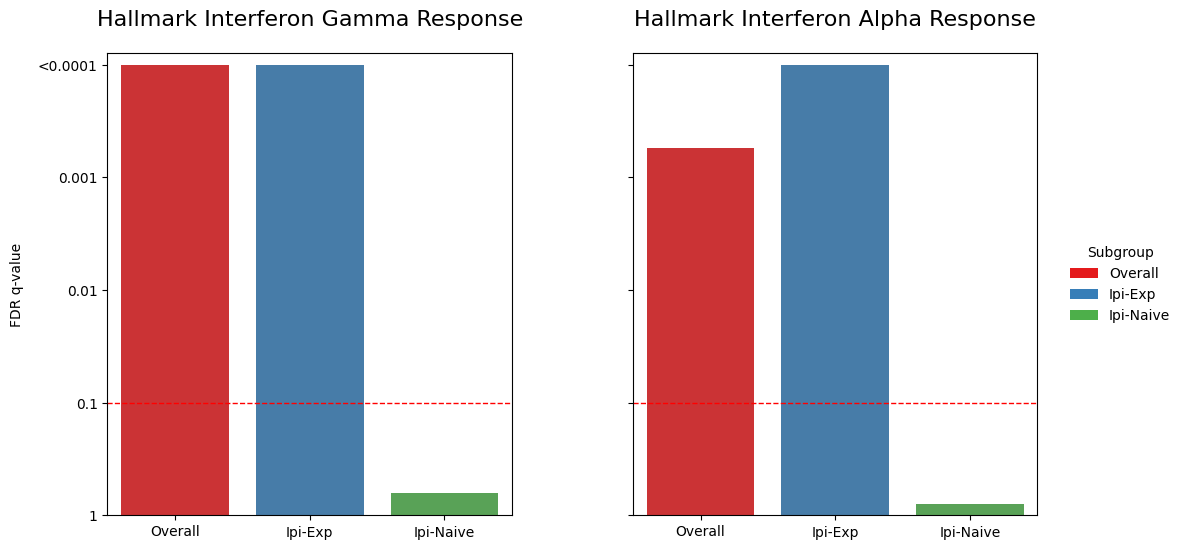

In [17]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

fig = plt.figure(figsize=(12, 6)) 
nrows = 1
ncols = 2
# No need for height_ratios or width_ratios for a simple 1x2 grid unless specific proportions are needed.
gs = gridspec.GridSpec(nrows, ncols, wspace=0.3) # Increased wspace for more gap between plots

# Define a color palette for the subgroups to match your image
# Assuming 'Overall' is red, 'Ipi-Exp' is blue, 'Ipi-Naive' is green
custom_palette = {'Overall': '#E41A1C', 'Ipi-Exp': '#377EB8', 'Ipi-Naive': '#4DAF4A'}

# Define the custom legend handles and labels based on your desired order
legend_labels = subgroups # ['Overall', 'Ipi-Exp', 'Ipi-Naive']
legend_handles = [Rectangle((0, 0), 1, 1, fc=custom_palette[subgroup]) 
                  for subgroup in legend_labels]
for i, pathway in enumerate(pathways):
    ax = plt.subplot(gs[0, i]) # Access subplots in the first row
    
    # Filter data for the current pathway
    plot_data = graphDF_final[graphDF_final["Pathway"] == pathway]

    sns.barplot(ax=ax, 
                x='Subgroup', 
                y='-Log10Qvalue', 
                hue='Subgroup', 
                data=plot_data, 
                dodge=False, # Important: prevents bars from shifting if x and hue are the same
                palette=custom_palette # Apply custom colors
               )
    
    # Set titles for each subplot
    title = pathway.replace("_", " ").title()
    ax.set_title(title, fontsize=16, pad=20) # Pad adds space between title and plot

    # Y-axis ticks and labels
    yticks_val = [0, 1, 2, 3, 4]
    yticklabels_val = ['1', '0.1', '0.01', '0.001', '<0.0001']
    ax.set_yticks(yticks_val)
    ax.set_yticklabels(yticklabels_val)
    
    # Significance line at -Log10(0.1) = 1
    yline = 1.0 
    xlim_max = len(subgroups) - 0.5 # For 3 subgroups, x goes from -0.5 to 2.5
    ax.plot([-0.5, xlim_max], [yline, yline], color='red', linestyle='--', linewidth=1)
    
    # Set X and Y limits
    ax.set_xlim(-0.5, xlim_max)
    ax.set_ylim(0, 4.1) # Start y-axis from 0 to avoid cut-off at the bottom
    
    # X-axis label
    ax.set_xlabel("")
    
    # Y-axis label only for the first subplot
    if i == 0:
        ax.set_ylabel("FDR q-value", labelpad=10)
    else:
        ax.set_ylabel("") # Hide y-label for the second subplot
        ax.tick_params(axis='y', labelleft=False) # Hide y-tick labels as well
        
    if i == 1:
        ax.legend(legend_handles, legend_labels, 
          loc='center left', 
          bbox_to_anchor=(1.05, 0.5), 
          title="Subgroup", 
          frameon=False)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the legend on the right
plt.show()